<a href="https://colab.research.google.com/github/lanzg/api-gateway-demo-sign-java/blob/master/recoloring.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!git clone https://github.com/compphoto/Intrinsic
!cd Intrinsic/ && pip install .

Cloning into 'Intrinsic'...
remote: Enumerating objects: 224, done.
remote: Counting objects: 100% (57/57), done.
remote: Compressing objects: 100% (24/24), done.
remote: Total 224 (delta 43), reused 33 (delta 33), pack-reused 167 (from 2)
Receiving objects: 100% (224/224), 37.42 MiB | 22.11 MiB/s, done.
Resolving deltas: 100% (105/105), done.
Processing /content/Intrinsic
  Preparing metadata (setup.py) ... done
  Cloning https://github.com/CCareaga/MiDaS (to revision fb51e3a) to /tmp/pip-install-n7p4zmpx/altered-midas_bffa44309ae940eb977fb08eb8b118b0
  Running command git clone --filter=blob:none --quiet https://github.com/CCareaga/MiDaS /tmp/pip-install-n7p4zmpx/altered-midas_bffa44309ae940eb977fb08eb8b118b0
  Running command git checkout -q fb51e3a
  Resolved https://github.com/CCareaga/MiDaS to commit fb51e3a
  Preparing metadata (setup.py) ... done
  Cloning https://github.com/CCareaga/chrislib (to revision 9a4c63f) to /tmp/pip-install-n7p4zmpx/chrislib_68a455a7464a42f195ef0a73b8

In [2]:
import torch

# import some helper functions from chrislib (will be installed by the intrinsic repo)
from chrislib.general import show, view, uninvert, match_scale
from chrislib.data_util import load_image

# import model loading and running the pipeline
from intrinsic.pipeline import run_gray_pipeline, load_models

In [3]:
intrinsic_model = load_models('paper_weights')

Downloading: "https://github.com/compphoto/Intrinsic/releases/download/v1.0/final_weights.pt" to /root/.cache/torch/hub/checkpoints/final_weights.pt


100%|██████████| 485M/485M [00:11<00:00, 44.8MB/s]


Downloading: "https://github.com/facebookresearch/WSL-Images/zipball/main" to /root/.cache/torch/hub/main.zip
Downloading: "https://download.pytorch.org/models/ig_resnext101_32x8-c38310e5.pth" to /root/.cache/torch/hub/checkpoints/ig_resnext101_32x8-c38310e5.pth


100%|██████████| 340M/340M [00:08<00:00, 43.3MB/s]
/usr/local/lib/python3.12/dist-packages/torch/hub.py:247: UserWarning: You are about to download and run code from an untrusted repository. In a future release, this won't be allowed. To add the repository to your trusted list, change the command to load(..., trust_repo=False) and a command prompt will appear asking for an explicit confirmation of trust, or load(..., trust_repo=True), which will assume that the prompt is to be answered with 'yes'. You can also use load(..., trust_repo='check') which will only prompt for confirmation if the repo is not already trusted. This will eventually be the default behaviour
  _check_repo_is_trusted(


Downloading: "https://github.com/rwightman/gen-efficientnet-pytorch/zipball/master" to /root/.cache/torch/hub/master.zip


In [4]:
# three different example scenes from the paper
scene_name = 'yellow_chair'
# scene_name = 'brown_chairs'
# scene_name = 'spain_museum'

In [5]:
inp = load_image(f'Intrinsic/examples/{scene_name}/input.png')[:, :, :3]
msk = load_image(f'Intrinsic/examples/{scene_name}/mask.png')[:, :, :3]
tex = load_image(f'Intrinsic/examples/{scene_name}/texture.png')[:, :, :3] ** 2.2

In [6]:
results = run_gray_pipeline(
    intrinsic_model,
    inp,
    resize_conf=None,
    maintain_size=True
)

alb = results['gry_alb']
image = results['image']
inv_shd = results['gry_shd']

shd = uninvert(inv_shd)[:, :, None]

In [7]:
def perform_recolor(msk, alb, shd, shd_power=1.0, recolor=None):
    # this function will perform the illumination-aware recoloring, or apply a shading curve
    # msk - numpy array (HxWx1) denoting the region to perform the edit
    # alb - linear albedo of the image
    # shd - linear shading of the image
    # shd_power - exponent to apply to the shading (<1 for more diffuse, >1 for more specular)
    # recolor - a texture to apply to the edited region, no recoloring is performed if set to None

    if recolor is None:
        our_new_alb = alb
    else:
        # we match the scale of the texture to the albedo in the edited region to
        # ensure the appearance of the region is maintained, but this can be altered
        recolor = match_scale(recolor, alb, msk.astype(bool))
        our_new_alb = ((1.0 - msk) * alb) + (msk * recolor)

    # apply exponentiation to the shading of the region and composite
    masked_shd = msk * (shd ** shd_power)
    new_shd = ((1.0 - msk) * shd) + masked_shd

    # combine edited albedo and shading, gamma correct and clip
    recolored = (our_new_alb * new_shd) ** (1/2.2)

    return recolored.clip(0, 1)

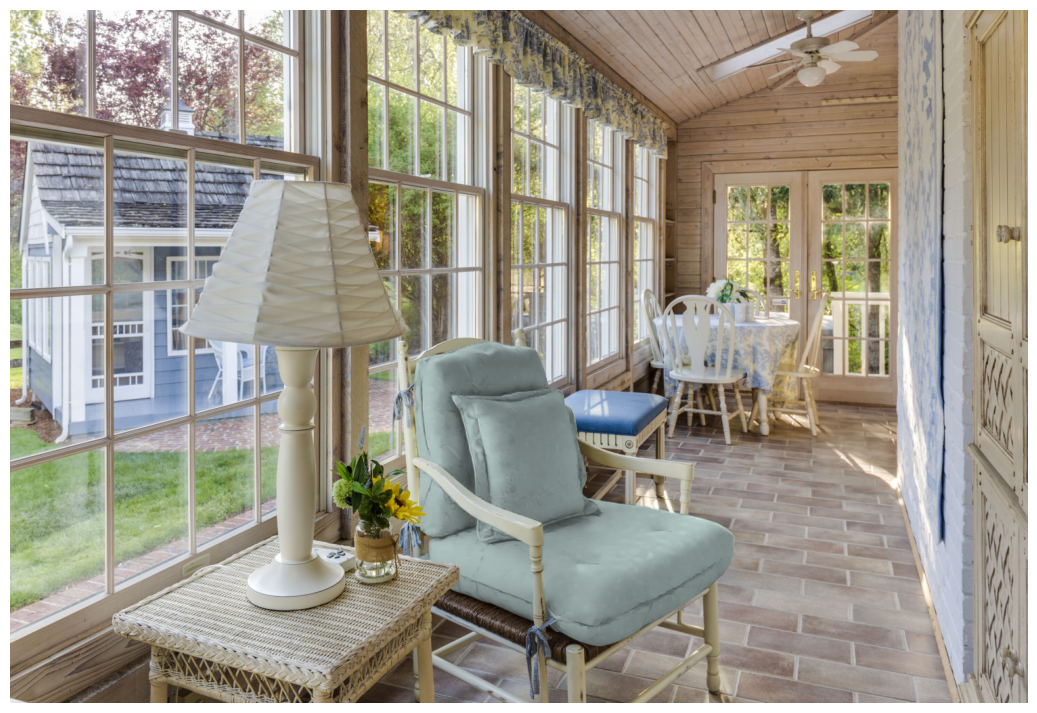

In [8]:
# NOTE: setting the shading exponent to >1 will make the shading appear more specular,
# but small errors in the shading (albedo leakage) will be amplified in some cases
show(perform_recolor(msk, alb, shd, 1.0, recolor=tex))